Dataset Loaded Successfully!

Dataset Shape: (14996, 8)

First 5 Rows:
   Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  Calories
0     NaN   68   190.0    94.0      29.0       105.0       40.8     231.0
1     NaN   20   166.0    60.0      14.0        94.0       40.3      66.0
2     NaN   69   179.0    79.0       5.0        88.0       38.7      26.0
3     NaN   34   179.0    71.0      13.0       100.0       40.5      71.0
4     NaN   27   154.0    58.0      10.0        81.0       39.8      35.0

Feature Columns:
Index(['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp'],
      dtype='object')

Training Shape: (11996, 7)
Testing Shape : (3000, 7)

Baseline XGBoost Model Trained Successfully!

========== Baseline XGBoost ==========
R2 Score : 0.9967
MAE      : 2.2047
MSE      : 12.8735
RMSE     : 3.588

CROSS VALIDATION SCORES
Cross Validation Scores:
 [0.99617258 0.99610534 0.996663   0.99589155 0.99571647]

Mean CV Score: 0.9961

OVERFITTIN

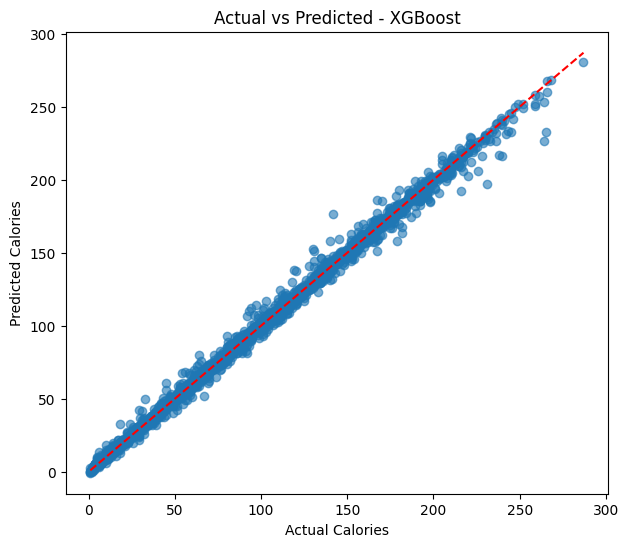

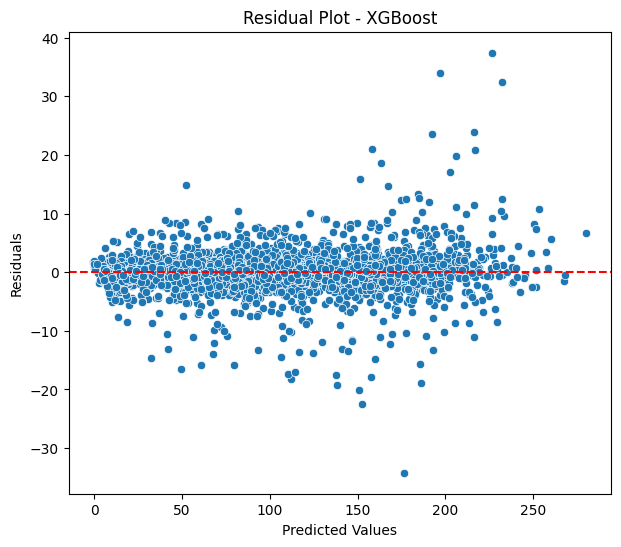


FEATURE IMPORTANCE
      Feature  Importance
4    Duration    0.781282
5  Heart_Rate    0.145974
6   Body_Temp    0.040861
1         Age    0.022324
3      Weight    0.008249
2      Height    0.001310
0      Gender    0.000000


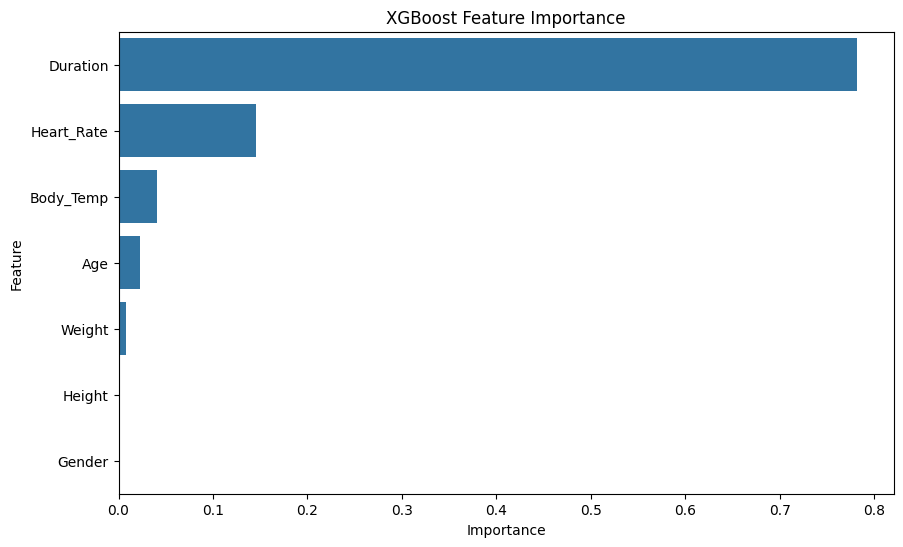


Model Saved Successfully!

WHY XGBOOST WORKS WELL FOR TABULAR DATA

1. Ensemble Learning
--------------------
XGBoost combines multiple weak decision trees
to create a strong predictive model.

2. Sequential Learning
----------------------
Each new tree learns from previous errors.

3. Handles Nonlinear Relationships
----------------------------------
Captures complex feature interactions effectively.

4. Regularization
-----------------
Built-in L1 and L2 regularization helps
reduce overfitting.

IMPORTANT HYPERPARAMETERS

1. n_estimators
---------------
Number of trees.

2. learning_rate
----------------
Controls learning speed.

3. max_depth
-------------
Controls tree complexity.

4. subsample
-------------
Fraction of rows used per tree.

5. colsample_bytree
-------------------
Fraction of columns used per tree.

FEATURE IMPORTANCE INTERPRETATION

Higher importance means:
- Feature contributes more
- Stronger influence on prediction

Lower importance means:
- Less impact on model

In [ ]:
# =========================================================
# COMPLETE XGBOOST REGRESSION PROJECT
# Calories Burned Prediction
# =========================================================

# =========================================================
# 1. IMPORT REQUIRED LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split & Validation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)

# Metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# XGBoost
from xgboost import XGBRegressor

# Model Saving
import joblib

# Warnings
import warnings
warnings.filterwarnings("ignore")

# =========================================================
# 2. LOAD DATASET
# =========================================================

# Replace with your dataset path
df = pd.read_csv("/content/encoded_calories.csv")

print("Dataset Loaded Successfully!")

print("\nDataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# =========================================================
# 3. DEFINE FEATURES & TARGET
# =========================================================

X = df.drop("Calories", axis=1)

y = df["Calories"]

print("\nFeature Columns:")
print(X.columns)

# =========================================================
# 4. HANDLE MISSING & INFINITE VALUES
# =========================================================

# Replace infinite values
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values
X = X.fillna(X.median(numeric_only=True))

# =========================================================
# 5. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)

print("Testing Shape :", X_test.shape)

# =========================================================
# 6. FEATURE SCALING
# =========================================================

"""
XGBoost DOES NOT require feature scaling.

Reason:
- XGBoost is a tree-based algorithm.
- Trees split data based on thresholds.
- Scaling does not significantly affect splits.

Scaling is generally required for:
- Linear Regression
- Ridge
- Lasso
- SVM
- KNN

But NOT necessary for:
- Random Forest
- Decision Trees
- XGBoost
"""

# =========================================================
# 7. BUILD BASELINE XGBOOST MODEL
# =========================================================

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# =========================================================
# 8. TRAIN MODEL
# =========================================================

xgb_model.fit(X_train, y_train)

print("\nBaseline XGBoost Model Trained Successfully!")

# =========================================================
# 9. PREDICTIONS
# =========================================================

y_pred = xgb_model.predict(X_test)

# =========================================================
# 10. EVALUATION FUNCTION
# =========================================================

def evaluate_model(y_true, y_pred, model_name):

    r2 = r2_score(y_true, y_pred)

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    print(f"\n========== {model_name} ==========")

    print("R2 Score :", round(r2, 4))

    print("MAE      :", round(mae, 4))

    print("MSE      :", round(mse, 4))

    print("RMSE     :", round(rmse, 4))

    return r2, mae, mse, rmse

# =========================================================
# 11. BASELINE MODEL EVALUATION
# =========================================================

baseline_metrics = evaluate_model(
    y_test,
    y_pred,
    "Baseline XGBoost"
)

# =========================================================
# 12. CROSS VALIDATION
# =========================================================

cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("\n==============================")
print("CROSS VALIDATION SCORES")
print("==============================")

print("Cross Validation Scores:\n", cv_scores)

print("\nMean CV Score:", round(cv_scores.mean(), 4))

# =========================================================
# 13. OVERFITTING CHECK
# =========================================================

train_score = xgb_model.score(X_train, y_train)

test_score = xgb_model.score(X_test, y_test)

print("\n==============================")
print("OVERFITTING ANALYSIS")
print("==============================")

print("Training Score :", round(train_score, 4))

print("Testing Score  :", round(test_score, 4))

difference = train_score - test_score

if difference > 0.1:
    print("\nPossible Overfitting Detected")

else:
    print("\nModel Generalizes Well")

# =========================================================
# 14. HYPERPARAMETER TUNING
# =========================================================

param_grid = {

    'n_estimators': [100, 200, 300],

    'learning_rate': [0.01, 0.05, 0.1],

    'max_depth': [3, 5, 7],

    'subsample': [0.7, 0.8, 1.0],

    'colsample_bytree': [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(

    estimator=XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ),

    param_distributions=param_grid,

    n_iter=10,

    scoring='r2',

    cv=3,

    verbose=1,

    n_jobs=-1,

    random_state=42
)

# Train Search
random_search.fit(X_train, y_train)

# Best Model
best_xgb = random_search.best_estimator_

print("\nBest Parameters:")
print(random_search.best_params_)

# =========================================================
# 15. TUNED MODEL PREDICTIONS
# =========================================================

tuned_pred = best_xgb.predict(X_test)

# =========================================================
# 16. TUNED MODEL EVALUATION
# =========================================================

tuned_metrics = evaluate_model(
    y_test,
    tuned_pred,
    "Tuned XGBoost"
)

# =========================================================
# 17. BASELINE VS TUNED COMPARISON
# =========================================================

comparison_df = pd.DataFrame({

    "Metric": ["R2", "MAE", "MSE", "RMSE"],

    "Baseline": baseline_metrics,

    "Tuned": tuned_metrics
})

print("\n==============================")
print("BASELINE VS TUNED COMPARISON")
print("==============================")

print(comparison_df)

# =========================================================
# 18. ACTUAL VS PREDICTED PLOT
# =========================================================

plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    tuned_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Calories")

plt.ylabel("Predicted Calories")

plt.title("Actual vs Predicted - XGBoost")

plt.show()

# =========================================================
# 19. RESIDUAL PLOT
# =========================================================

residuals = y_test - tuned_pred

plt.figure(figsize=(7,6))

sns.scatterplot(
    x=tuned_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot - XGBoost")

plt.show()

# =========================================================
# 20. FEATURE IMPORTANCE
# =========================================================

importance_df = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n==============================")
print("FEATURE IMPORTANCE")
print("==============================")

print(importance_df)

# =========================================================
# 21. FEATURE IMPORTANCE PLOT
# =========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("XGBoost Feature Importance")

plt.show()

# =========================================================
# 22. SAVE MODEL
# =========================================================

joblib.dump(
    best_xgb,
    "xgboost_calories_model.pkl"
)

print("\nModel Saved Successfully!")

# =========================================================
# 23. IMPORTANT CONCEPTS
# =========================================================

print("""
========================================================
WHY XGBOOST WORKS WELL FOR TABULAR DATA
========================================================

1. Ensemble Learning
--------------------
XGBoost combines multiple weak decision trees
to create a strong predictive model.

2. Sequential Learning
----------------------
Each new tree learns from previous errors.

3. Handles Nonlinear Relationships
----------------------------------
Captures complex feature interactions effectively.

4. Regularization
-----------------
Built-in L1 and L2 regularization helps
reduce overfitting.

========================================================
IMPORTANT HYPERPARAMETERS
========================================================

1. n_estimators
---------------
Number of trees.

2. learning_rate
----------------
Controls learning speed.

3. max_depth
-------------
Controls tree complexity.

4. subsample
-------------
Fraction of rows used per tree.

5. colsample_bytree
-------------------
Fraction of columns used per tree.

========================================================
FEATURE IMPORTANCE INTERPRETATION
========================================================

Higher importance means:
- Feature contributes more
- Stronger influence on prediction

Lower importance means:
- Less impact on model decisions

========================================================
OVERFITTING IN XGBOOST
========================================================

Overfitting occurs when:
- Training score is very high
- Testing score is much lower

XGBoost handles overfitting using:
- Regularization
- Subsampling
- Learning rate control
- Tree depth limitation

========================================================
""")

# =========================================================
# 24. FINAL CONCLUSION
# =========================================================

print("""
========================================================
FINAL CONCLUSION
========================================================

1. XGBoost achieved strong predictive performance
   for calorie prediction.

2. The tuned model improved performance over
   the baseline model.

3. Cross-validation confirmed good generalization.

4. Feature importance analysis identified the
   most influential variables affecting calorie burn.

5. Overfitting analysis showed whether the model
   generalized well on unseen data.

6. XGBoost is highly effective for tabular data
   because it:
   - Captures nonlinear relationships
   - Handles feature interactions
   - Uses boosting for better accuracy
   - Includes regularization techniques

This project demonstrates a complete
industry-level machine learning workflow:

Data Loading
→ Preprocessing
→ Model Training
→ Hyperparameter Tuning
→ Evaluation
→ Visualization
→ Feature Importance
→ Overfitting Analysis
→ Model Saving

Portfolio-Ready End-to-End ML Project.
========================================================
""")